# Multiclass Text Classification with Word2Vec model

In [ ]:
import pandas as pd #Data manipulation
import numpy as np
from scipy.stats import randint
import seaborn as sns # used for plot interactive graph.
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

from sklearn.feature_selection import chi2
from IPython.display import display
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from gensim.models import Word2Vec
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline


from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler




In [ ]:
new_header = ['id', 'Movie name', 'Genre', 'Movie description'] #assigning headers since txt file doesn't have header


df = pd.read_csv("sample_data/train_data.txt", header=None, names=new_header, sep=':::', engine='python')

### Exploration and Preprocessing

In [ ]:
df.head(2) #this way you can display columns as rows.

,id,Movie name,Genre,Movie description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...


Let's remove some information that we do not need and build another dataframe that contain Genre and movie description.

In [ ]:
# Create a new dataframe with two columns
df1 = df[['Genre', 'Movie description']].copy()

# Remove missing values (NaN)
df1 = df1[pd.notnull(df1['Movie description'])]

df1.shape

(54214, 2)

In [ ]:
# Percentage of movie description that had text field
total = df1['Movie description'].notnull().sum()
round((total/len(df)*100),1)

100.0

In [ ]:
pd.DataFrame(df1.Genre.unique()).values
#print(len(pd.DataFrame(df1.Genre.unique()).values))

array([[' drama '],
       [' thriller '],
       [' adult '],
       [' documentary '],
       [' comedy '],
       [' crime '],
       [' reality-tv '],
       [' horror '],
       [' sport '],
       [' animation '],
       [' action '],
       [' fantasy '],
       [' short '],
       [' sci-fi '],
       [' music '],
       [' adventure '],
       [' talk-show '],
       [' western '],
       [' family '],
       [' mystery '],
       [' history '],
       [' news '],
       [' biography '],
       [' romance '],
       [' game-show '],
       [' musical '],
       [' war ']], dtype=object)

There are 27 different classes or categories that we can use as out target variable.

In [ ]:
# let's work with a smaller smaple of the data to speed things up
df2 = df1.sample(10000, random_state=1).copy() #CBOW model
df3 = df1.sample(10000, random_state=2).copy() #Skip gram model
#df2 = df1.copy() #CBOW model
#df3 = df1.copy() #Skip gram model

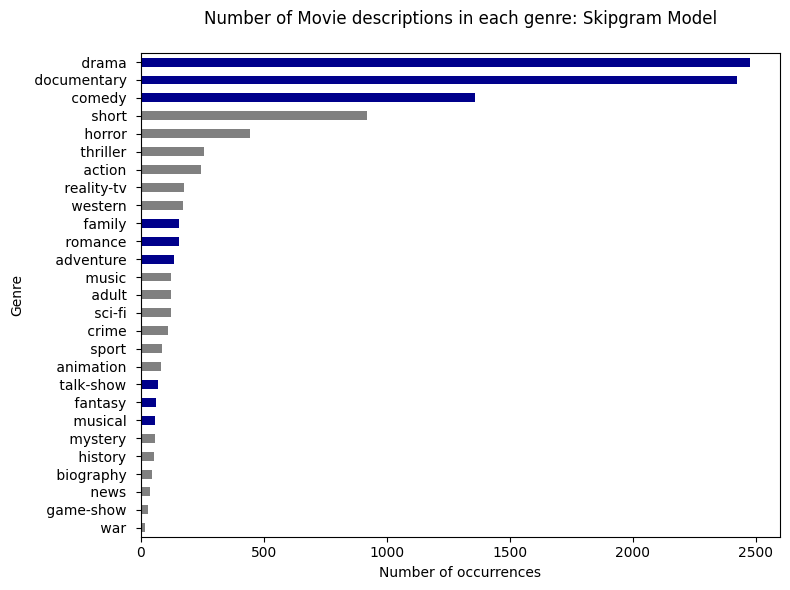

In [ ]:
fig = plt.figure(figsize=(8, 6))
colors = ['grey', 'grey', 'grey', 'grey', 'grey', 'grey', 'darkblue', 'darkblue', 'darkblue']

df3.groupby('Genre')['Movie description'].count().sort_values().plot.barh(
    color=colors, title='Number of Movie descriptions in each genre: Skipgram Model\n'
)

plt.xlabel('Number of occurrences', fontsize=10)
plt.tight_layout()
plt.show()

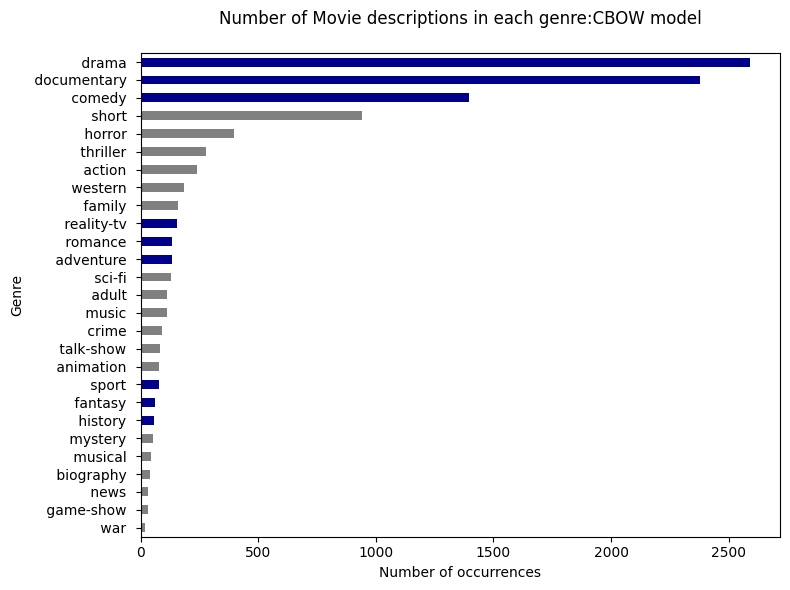

In [ ]:
fig = plt.figure(figsize=(8, 6))
colors = ['grey', 'grey', 'grey', 'grey', 'grey', 'grey', 'darkblue', 'darkblue', 'darkblue']

df2.groupby('Genre')['Movie description'].count().sort_values().plot.barh(
    color=colors, title='Number of Movie descriptions in each genre:CBOW model\n'
)

plt.xlabel('Number of occurrences', fontsize=10)
plt.tight_layout()
plt.show()

Our dataset is highly unbalanced.
So undersampling in major datasets and oversampling in lower datasets to balance the datsets

In [ ]:
# Create a new column 'Tokenized_text' to tokenise the movie description
df3['Tokenized_Text'] = df3['Movie description'].apply(lambda x: x.lower().split())

df3.head(3)

,Genre,Movie description,Tokenized_Text
49672,drama,A bizarre couple and their seventeen-year-old...,"[a, bizarre, couple, and, their, seventeen-yea..."
48949,short,The world has been taken over by The Unknown....,"[the, world, has, been, taken, over, by, the, ..."
15204,drama,The drama tells the story about a variety of ...,"[the, drama, tells, the, story, about, a, vari..."


In [ ]:
# Create a new column 'Tokenized_Text' to tokenise the movie description
df2['Tokenized_Text'] = df2['Movie description'].apply(lambda x: x.lower().split())


# New dataframe
df2.head(2)

,Genre,Movie description,Tokenized_Text
10689,documentary,This documentary film is a heartfelt glimpse ...,"[this, documentary, film, is, a, heartfelt, gl..."
32392,short,"According to an old Chinese fairytale, the go...","[according, to, an, old, chinese, fairytale,, ..."


Let us now calculate Word2Vec scores.

CBOW model and SKip gram model

In [ ]:
# Training the Word2Vec model on tokenized text

# Using CBOW (default, sg=0)
model_cbow = Word2Vec(sentences= df2['Tokenized_Text'], vector_size=100, window=5, sg=0)

# Using Skip-Gram (sg=1)
#model_skipgram = Word2Vec(sentences= df3['Tokenized_Text'], vector_size=100, window=5, sg=1)



In [ ]:
# Function to compute sentence vector by averaging word vectors
def compute_sentence_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)  # Return a zero vector if no words are in the vocabulary

# Compute Word2Vec scores for each sentence
df2['Word2Vec_Score_cbow'] = df2['Tokenized_Text'].apply(lambda x: compute_sentence_vector(x, model_cbow))

#df3['Word2Vec_Score_skipgram'] = df3['Tokenized_Text'].apply(lambda x: compute_sentence_vector(x, model_skipgram))

### Classification

Let us train several models, namely,

*   Random Forest
*   Linear Support Vector Machine

*   Logistic Regression

In [ ]:
classifiers = [
        ('RandomForest', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=0)),
        ('LinearSVC', LinearSVC(random_state=0, max_iter=10000)),
        ('LogisticRegression', LogisticRegression(random_state=0, max_iter=10000)),
    ]

# Initialize a list to store cross-validation results
cv_results = []

# Define the number of cross-validation folds
CV = 5
skf = StratifiedKFold(n_splits=CV, shuffle=True, random_state=1)


for name, classifier in classifiers:
        # Create a pipeline with scaling and the classifier
        pipeline = ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote', SMOTE(sampling_strategy='auto', random_state=1)),
            ('undersampler', RandomUnderSampler(sampling_strategy= 'auto', random_state=1)),
            (name, classifier)
        ])

        # Perform cross-validation
        scores = cross_val_score(pipeline, features, labels_encoded, cv=skf, scoring='accuracy')

        # Store the results
        for fold_idx, score in enumerate(scores):
            cv_results.append({
                'model_name': name,
                'fold_idx': fold_idx + 1,
                'accuracy': score
            })

# Convert the results to a DataFrame
cv_df = pd.DataFrame(cv_results)


print("Cross-Validation Results:")
print(cv_df.groupby('model_name')['accuracy'].agg(['mean', 'std']).reset_index())




Cross-Validation Results:
           model_name    mean       std
0           LinearSVC  0.1250  0.009868
1  LogisticRegression  0.1665  0.011953
2        RandomForest  0.0528  0.003528
